# Author characteristics and collaborative structure

This notebook consolidates the former `05_*` author, gender, geography, institution, and network analyses into one reproducible workflow. Showcase+ is the canonical publication, authorship, venue, institution, and geography source. Figure 3G additionally reuses the frozen field-and-year-normalized citation pathway from analysis 03, with its retained resolved-author summary as an explicit fallback when the ignored per-paper cache is unavailable. All transformations, statistics, validation rules, plots, captions, and exports live in `utils.data_analysis_05_author_characteristics` and `utils.data_analysis_05_author_plots`, with reusable figure scaffolding in `utils.shared_style`; the notebook records the analytical decisions and orchestrates those utilities.

The deliverables are one eight-panel headline figure in PNG and PDF formats, six domain-specific supplementary figures, an author-indexed top-30 table in CSV and editable Word formats, a complete author-level table containing UK Biobank-specific impact and network measures, domain tables, a supplementary workbook, figure captions, methods text, validation checks, and an artifact manifest. All displayed and saved paths are repository-relative.

Every figure below is drawn in the one project palette (`shared_style.PALETTE_COLORS`, D29): `style.notebooks.05_author_characteristics` in `universal_settings.yml` holds those seven colours in `PALETTE` order, and the semantic maps above it — `domain_colors`, `author_metric_colors`, `gender_colors`, `component_colors` — name what each one means, so a colour identity is set in one place rather than in a draw function. Continuous scales are `sequential_colormap(<a palette colour>)` for the same reason. The only colours the plot module still writes by hand are neutral greys, for things that are not categories: missing map records, annotation arrows, and the closing "Other" band on the FOR bars.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "src" / "utils").is_dir())
sys.path.insert(0, str(ROOT / "src"))

from utils import data_analysis_05_author_characteristics as A
from utils import data_analysis_05_author_plots as F
from utils import shared_name_gender as G
from utils import shared_paths as P
from utils.shared_style import load_style, render_figure

P.bootstrap()
P.ensure_dirs()
STYLE = load_style("05_author_characteristics")
ARTIFACTS = P.ArtifactRegistry(P.TABLE_AUTHOR_CHARACTERISTICS)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 90)
print("Input:", P.raw_path(P.SHOWCASE_PLUS))
print("Figures:", P.raw_path(P.FIG_AUTHOR_CHARACTERISTICS))
print("Tables:", P.raw_path(P.TABLE_AUTHOR_CHARACTERISTICS))

Input: data/showcase/showcase_plus/showcase_plus_all_endpoints_wide.parquet
Figures: output/figures/data_analysis/05_author_characteristics
Tables: output/tables/data_analysis/05_author_characteristics


## Analytical design

All publication cohorts, including author impact and venue rankings, run from 1 January 2013 through 31 December 2025. The retained citation counts use the August 2026 snapshot; that snapshot date is separate from the publication cutoff.

The analysis distinguishes publications, author-paper pairs, affiliations, and longitudinally resolved authors. Dimensions `researcher_id` values are the only cross-paper identity key. Missing IDs receive paper-local keys for descriptive denominators and are never merged by name. This avoids falsely combining namesakes, although it means unresolved authorships cannot contribute to person-level h-indices or network trajectories.

Each paper contributes one fractional publication unit, split first among parsed authors and then among each author's distinct institutions or countries. FOR 2020 categories remain multi-label. Name-based Female/Male/Unknown categories are reported as an imperfect proxy rather than self-identified gender. The shared pipeline preserves strict and expanded dictionary sensitivities, combines five package-bundled offline name datasets with explicit conflict rules, makes no API calls, and links records within a Dimensions researcher ID only when all direct classifications agree. Coverage, per-library votes, methods, unresolved reasons, and conflicts are shown explicitly. Network results use both observed ties and team-size-normalized weights, with a parallel sensitivity excluding papers with more than 100 resolved authors. The promoted author-impact panel remains restricted to resolved identities and separates paper volume, mean normalized citation score, UKB h-index, and first/last/sole-author share rather than collapsing them into one rank.

In [2]:
source, papers = A.load_author_papers()
parameters = A.analysis_parameters(source, papers)
display(parameters)
display(A.metric_definitions())

,parameter,value
0,input,data/showcase/showcase_plus/showcase_plus_all_endpoints_wide.parquet
1,source_records,26109
2,primary_records,23442
3,first_year,2013
4,analysis_start_date,2013-01-01
5,last_complete_year,2025
6,analysis_end_date,2025-12-31
7,provisional_years_excluded,2026
8,author_identity,Dimensions researcher_id
9,unresolved_identity,paper-local key; no cross-paper linkage


,metric,definition
0,Resolved author,An authorship carrying a Dimensions researcher_id; only these IDs are linked longitudi...
1,Unresolved authorship,An author-paper slot without a researcher_id. It receives a paper-local key and is nev...
2,UKB h-index,Largest h for which an author or institution has h UK Biobank papers cited at least h ...
3,UKB g-index,Largest g for which the g most-cited UK Biobank papers received at least g squared cit...
4,Top-author ranking,"Resolved authors ordered by UKB h-index, with ties broken by UKB publication count, to..."
5,Mean normalized citation score (MNCS),"For each paper, citations divided by the mean for its publication year and FOR L4 fiel..."
6,Leadership share,Share of an author's citation-window papers on which that resolved author occupied the...
7,Venue citation stock,Current Showcase+ citations summed over papers assigned to a source title; this is a s...
8,Fractional publication credit,"Each paper contributes one unit split equally among parsed authors, then equally among..."
9,Author-credit concentration,Cumulative share of resolved-author fractional publication credit held by authors rank...


## Top 30 authors by individual UK Biobank h-index

This table ranks Dimensions-resolved authors using only their 2013–2025 UK Biobank publications. It is calculated directly from the canonical papers, so it can be exported before name inference, network construction or the field-normalised citation pathway. Author names form the index; columns give rank, UKB h-index, paper count, total and mean citations, i10-index and fractional publication credit. Ties are broken by paper count, total citations, name and researcher ID. Citations are cumulative values recorded in Showcase+. The CSV and editable landscape Word table contain the same values.


In [3]:
top_authors = A.build_top_author_publication_metrics(papers)
top_author_exports = A.export_top_author_table(ARTIFACTS, top_authors)
display(top_author_exports["table"])


saved output/tables/data_analysis/05_author_characteristics/top_30_authors_by_ukb_h_index.csv
saved output/tables/data_analysis/05_author_characteristics/top_30_authors_by_ukb_h_index.docx


,Rank,UKB h-index,UKB papers,Total UKB citations,Mean citations per paper,UKB i10-index,Fractional publication credit
Author,,,,,,,
George Davey Smith,1,77,329,28121,85.5,187,39.31
Ian J. Deary,2,72,222,30374,136.8,152,18.13
Naveed Sattar,3,72,192,26518,138.1,145,17.06
Nicholas J. Wareham,4,72,163,34720,213.0,129,8.00
Jill P. Pell,5,71,254,28895,113.8,168,28.37
Kari Stefansson,6,68,167,34234,205.0,137,3.94
Stephen Burgess,7,62,216,15868,73.5,143,27.71
Caroline Hayward,8,62,165,28503,172.7,125,5.61
Nicholas G. Martin,9,62,141,28521,202.3,110,4.49


## Canonical author, affiliation, geography, institution, and gender tables

The next call performs all non-network transformations once. In particular, it preserves all reported affiliations rather than selecting an arbitrary first affiliation, resolves organization metadata from GRID IDs, computes paper-conserving fractional credits, and constructs UKB-specific author and institution bibliometrics.

In [4]:
core = A.build_core_tables(papers)
audit_pre_network = A.quality_audit(source, papers, core)
checks_pre_network = A.validation_checks(source, papers, core)
display(audit_pre_network)
display(checks_pre_network)
if not checks_pre_network["passed"].all():
    raise AssertionError("A pre-network validation check failed.")

,metric,value,interpretation
0,Source parquet records,26109.00,includes provisional years
1,Records before 2013,0.00,excluded from primary analysis
2,Records after 2025,2667.00,excluded from primary analysis
3,Complete-year papers,23442.00,2013-2025
4,Papers with parsed authors,23407.00,author-based denominator
5,Papers without parsed authors,35.00,retained in source audit only
6,Parsed author-paper pairs,274603.00,deduplicated within paper
7,Resolved author-paper pairs,242663.00,Dimensions researcher ID present
8,Unresolved author-paper pairs,31940.00,paper-local IDs; never merged by name
9,Unique resolved authors,69237.00,author table rows


,check,passed,observed,expected
0,unique_source_publication_ids,True,26109,26109
1,complete_year_window,True,2013-2025,2013-2025
2,publication_date_cutoff,True,23442,2025-12-31
3,unique_author_paper_pairs,True,274603,274603
4,authorship_credit_sums_to_one,True,0.0,<=1e-9
5,country_credit_never_exceeds_one,True,1.0,<=1
6,institution_credit_never_exceeds_one,True,1.0,<=1
7,institution_credit_conserved,True,0.0,<=1e-9
8,country_credit_conserved,True,0.0,<=1e-9
9,fractional_credits_nonnegative,True,nonnegative,nonnegative


## Author-level table and UK Biobank-specific impact

`core.author_metrics` contains one row per Dimensions-resolved author. The `ukb_h_index`, `ukb_g_index`, and `ukb_i10_index` columns use only papers in this UK Biobank corpus and therefore must not be interpreted as whole-career metrics. Network degree, component, and community columns are merged into this table after the network stage. A dedicated ranking below restores the former `05_authors_1_metrics` author table as a concise top-10 view while retaining the complete author table for reuse. The second table bundle below promotes the former analysis 03 author-portfolio and venue-ranking evidence into headline Figure 3G-H while retaining its distinct citation definitions.

In [5]:
author_preview_columns = [
    "researcher_id", "full_name", "n_ukb_papers", "fractional_paper_credit",
    "total_ukb_citations", "ukb_h_index", "ukb_g_index", "ukb_i10_index",
    "modal_institution", "modal_country", "modal_for_l2", "name_gender",
    "name_gender_method", "name_gender_unknown_reason",
]
display(core.author_metrics[author_preview_columns].head(25))
impact = A.build_headline_impact_tables(papers, core)
display(impact.provenance)
display(impact.author_labels[[
    "researcher_id", "author_name", "showcase_paper_count",
    "mean_impact_metric", "showcase_h_index", "leadership_share",
    "label_reason",
]])
display(impact.venue_plot.sort_values("total_citations", ascending=False))

,researcher_id,full_name,n_ukb_papers,fractional_paper_credit,total_ukb_citations,ukb_h_index,ukb_g_index,ukb_i10_index,modal_institution,modal_country,modal_for_l2,name_gender,name_gender_method,name_gender_unknown_reason
0,ur.010663343457.34,George Davey Smith,329,39.305765,28121.0,77,165,187,MRC Integrative Epidemiology Unit,United Kingdom,Health Sciences,Male,offline_ensemble_consensus,
1,ur.011026120037.74,Ian J. Deary,222,18.132695,30374.0,72,174,152,University of Edinburgh,United Kingdom,Psychology,Male,offline_ensemble_consensus,
2,ur.01026114310.09,Naveed Sattar,192,17.057790,26518.0,72,162,145,University of Glasgow,United Kingdom,Biomedical and Clinical Sciences,Male,offline_ensemble_consensus,
3,ur.013723776517.34,Nicholas J. Wareham,163,8.003276,34720.0,72,163,129,MRC Epidemiology Unit,United Kingdom,Biomedical and Clinical Sciences,Male,offline_ensemble_consensus,
4,ur.01354253237.14,Jill P. Pell,254,28.369818,28895.0,71,169,168,University of Glasgow,United Kingdom,Biomedical and Clinical Sciences,Unknown,unclassified,identity_conflict
5,ur.0723426172.10,Kari Stefansson,167,3.936184,34234.0,68,167,137,University of Iceland,Iceland,Biological Sciences,Unknown,unclassified,identity_conflict
6,ur.01223207223.05,Stephen Burgess,216,27.710578,15868.0,62,124,143,University of Cambridge,United Kingdom,Biomedical and Clinical Sciences,Male,offline_ensemble_consensus,
7,ur.01317433110.75,Caroline Hayward,165,5.614598,28503.0,62,165,125,MRC Human Genetics Unit,United Kingdom,Biological Sciences,Unknown,unclassified,identity_conflict
8,ur.010700366647.17,Nicholas G. Martin,141,4.489793,28521.0,62,141,110,QIMR Berghofer Medical Research Institute,Australia,Biological Sciences,Male,offline_ensemble_consensus,
9,ur.0616003437.07,Claudia Langenberg,132,5.654241,26259.0,61,132,100,MRC Epidemiology Unit,United Kingdom,Biological Sciences,Female,offline_ensemble_consensus,


,panel,measure,source,path,records_plotted
0,G,author mean MNCS and UKB h-index,recomputed from frozen 03 per-paper citation cache,data/analysis/academic_impact/for_counts_api/api_ukbb_records.json; data/analysis/acad...,10353
1,H,venue citation stock,Showcase+ citation snapshot,data/showcase/showcase_plus/showcase_plus_all_endpoints_wide.parquet,15


,researcher_id,author_name,showcase_paper_count,mean_impact_metric,showcase_h_index,leadership_share,label_reason
0,ur.010663343457.34,George Davey Smith,323,4.525652,76,0.126935,top-five publication count
1,ur.0754274002.97,Andrew M. McIntosh,233,4.793697,59,0.236052,top-five publication count
2,ur.01223207223.05,Stephen Burgess,210,5.651814,61,0.261905,high combined publication and h-index rank
3,ur.01354253237.14,Jill P. Pell,246,5.658898,70,0.182927,top-five publication count
4,ur.01120503505.13,Pradeep Natarajan,224,6.038227,56,0.446429,top-five publication count
5,ur.011026120037.74,Ian J. Deary,215,6.186709,71,0.190698,top-five h-index
6,ur.01026114310.09,Naveed Sattar,185,8.312817,72,0.167568,top-five h-index
7,ur.0723426172.10,Kari Stefansson,165,11.301850,69,0.278788,high combined publication and h-index rank


,venue,papers,total_citations,median_citations,median_citations_per_year,eligible_for_headline,headline_rank,selected_for_headline
14,Nature Genetics,256,81527,146.5,27.250000,True,1,True
13,Nature Communications,528,47796,36.0,8.500000,True,2,True
12,Nature,72,40355,174.0,45.375000,True,3,True
11,PLOS Medicine,59,19614,74.0,12.571429,True,4,True
10,American Journal of Human Genetics,198,13509,27.0,5.800000,True,5,True
9,NeuroImage,74,12320,20.0,4.250000,True,6,True
8,BMC Medicine,265,9846,23.0,5.600000,True,7,True
7,European Heart Journal,348,9832,0.0,0.000000,True,8,True
6,Scientific Reports,417,9347,10.0,2.500000,True,9,True
5,PLOS ONE,208,9111,11.0,2.000000,True,10,True


## Name-inferred gender, geography, and institutions

The annual name-category table includes Female, Male, and Unknown/androgynous counts; Wilson intervals apply only to integer author-paper pairs. Country and institution intersection tables use fractional credit and deliberately omit binomial intervals because fractional allocations are not independent Bernoulli trials.

In [6]:
display(G.inference_coverage(core.authorships).round(2))
display(G.inference_method_counts(core.authorships))
display(G.unresolved_query_queue(core.authorships).head(25))
display(core.gender_by_year.round(2))
display(core.gender_by_role.round(2))
display(core.country_metrics.head(15).round(2))
display(core.institution_metrics.head(15).round(2))

,stage,classified_author_paper_pairs,unknown_author_paper_pairs,total_author_paper_pairs,coverage_percent
0,Strict dictionary,160424,114179,274603,58.42
1,Expanded dictionary,168755,105848,274603,61.45
2,Offline ensemble,212627,61976,274603,77.43
3,Primary + identity linkage,217785,56818,274603,79.31


,name_gender_method,name_gender,name_gender_unknown_reason,author_paper_pairs
0,offline_ensemble_consensus,Male,,117143
1,offline_ensemble_consensus,Female,,71482
2,unclassified,Unknown,no_offline_prediction,40052
3,offline_single_source,Female,,10751
4,offline_single_source,Male,,9170
5,unclassified,Unknown,offline_library_conflict,7822
6,unclassified,Unknown,initials_only,5120
7,researcher_identity_consensus,Male,,4845
8,researcher_identity_consensus,Female,,3539
9,unclassified,Unknown,identity_conflict,3406


,query_name,author_paper_pairs,unique_resolved_authors,first_year,last_year,dictionary_result,offline_predictions,unknown_reason
0,Jie,712,138,2016,2025,andy,"gender_guesser=Unknown[andy] | gender_detector=Female[uk=Unknown,us=Unknown,ar=Unknown...",offline_library_conflict
1,Yu,623,164,2016,2025,andy,"gender_guesser=Unknown[andy] | gender_detector=Male[uk=Unknown,us=Unknown,ar=Male,uy=U...",offline_library_conflict
2,Yang,417,118,2017,2025,andy,"gender_guesser=Unknown[andy] | gender_detector=Male[uk=Unknown,us=Unknown,ar=Unknown,u...",offline_library_conflict
3,Qi,307,87,2015,2025,andy,"gender_guesser=Unknown[andy] | gender_detector=Male[uk=Unknown,us=Male,ar=Unknown,uy=U...",offline_library_conflict
4,Xiang,287,60,2018,2025,andy,"gender_guesser=Unknown[andy] | gender_detector=Male[uk=Male,us=Male,ar=Unknown,uy=Unkn...",offline_library_conflict
5,Jan,249,75,2016,2025,male,"gender_guesser=Male[male] | gender_detector=Male[uk=Unknown,us=Unknown,ar=Male,uy=Male...",offline_library_conflict
6,Kai,243,68,2017,2025,male,"gender_guesser=Male[male] | gender_detector=Male[uk=Unknown,us=Unknown,ar=Male,uy=Male...",offline_library_conflict
7,Qian,237,65,2018,2025,andy,"gender_guesser=Unknown[andy] | gender_detector=Male[uk=Unknown,us=Male,ar=Unknown,uy=U...",offline_library_conflict
8,Jill,229,1,2013,2025,female,"gender_guesser=Female[female] | gender_detector=Female[uk=Female,us=Female,ar=Female,u...",identity_conflict
9,Yuan,229,69,2018,2025,andy,"gender_guesser=Unknown[andy] | gender_detector=Male[uk=Unknown,us=Unknown,ar=Unknown,u...",offline_library_conflict


name_gender,year,Female,Male,Unknown,classified,total,female_name_share,unknown_name_share,female_name_ci_low,female_name_ci_high
0,2013,11.0,29.0,5.0,40.0,45.0,27.50,11.11,16.11,42.83
1,2014,86.0,150.0,17.0,236.0,253.0,36.44,6.72,30.56,42.75
2,2015,308.0,536.0,98.0,844.0,942.0,36.49,10.40,33.31,39.80
3,2016,1000.0,1858.0,369.0,2858.0,3227.0,34.99,11.43,33.26,36.76
4,2017,1872.0,3581.0,631.0,5453.0,6084.0,34.33,10.37,33.08,35.60
5,2018,3870.0,7406.0,1530.0,11276.0,12806.0,34.32,11.95,33.45,35.20
6,2019,5869.0,10298.0,1951.0,16167.0,18118.0,36.30,10.77,35.56,37.05
7,2020,6700.0,11281.0,2878.0,17981.0,20859.0,37.26,13.80,36.56,37.97
8,2021,8931.0,14914.0,3553.0,23845.0,27398.0,37.45,12.97,36.84,38.07
9,2022,10628.0,16490.0,6289.0,27118.0,33407.0,39.19,18.83,38.61,39.77


name_gender,authorship_role,Female,Male,Unknown,classified,total,female_name_share,unknown_name_share,female_name_ci_low,female_name_ci_high
0,First author,7458.0,9328.0,6327.0,16786.0,23113.0,44.43,27.37,43.68,45.18
1,Last author,5602.0,11980.0,5531.0,17582.0,23113.0,31.86,23.93,31.18,32.55
2,Middle author,72781.0,110392.0,44910.0,183173.0,228083.0,39.73,19.69,39.51,39.96
3,Single author,69.0,175.0,50.0,244.0,294.0,28.28,17.01,23.00,34.23
4,Corresponding author,6889.0,12344.0,7344.0,19233.0,26577.0,35.82,27.63,35.14,36.50


,iso3,fractional_paper_credit,unique_ukb_papers,first_ukb_year,last_ukb_year,country,iso2,unique_resolved_authors,author_affiliation_rows,classified_name_credit,female_name_credit,female_name_share,author_basis_unique_papers,authors_per_paper,org_basis_unique_papers,author_vs_org_paper_percent
0,CHN,6529.25,7715,2015,2025,China,CN,19213,56486,3095.06,1513.92,48.91,7715,7.32,7626,101.17
1,USA,5431.81,9050,2013,2025,United States,US,17150,68774,4620.14,1629.34,35.27,9050,7.60,8798,102.86
2,GBR,5181.82,8418,2013,2025,United Kingdom,GB,12971,61117,4654.75,1701.88,36.56,8418,7.26,8122,103.64
3,AUS,810.68,2168,2014,2025,Australia,AU,2184,9530,674.48,250.57,37.15,2168,4.40,2105,102.99
4,DEU,588.01,1890,2015,2025,Germany,DE,2804,9665,539.93,172.50,31.95,1890,5.11,1773,106.60
5,CAN,577.41,1473,2014,2025,Canada,CA,1882,6060,510.22,180.02,35.28,1473,4.11,1412,104.32
6,NLD,524.83,1802,2013,2025,Netherlands,NL,2107,8599,471.12,174.72,37.09,1802,4.77,1740,103.56
7,SWE,416.72,1653,2014,2025,Sweden,SE,1414,5369,371.25,167.15,45.02,1653,3.25,1619,102.10
8,KOR,373.71,590,2016,2025,South Korea,KR,999,3557,216.10,83.69,38.73,590,6.03,573,102.97
9,DNK,260.30,960,2015,2025,Denmark,DK,1085,4197,247.65,73.80,29.80,960,4.37,932,103.00


,institution_id,fractional_paper_credit,unique_ukb_papers,first_ukb_year,last_ukb_year,total_ukb_citations,mean_ukb_citations,median_ukb_citations,max_ukb_citations,total_altmetric,ukb_h_index,ukb_g_index,ukb_i10_index,institution,org_id,country,country_iso3,org_type,unique_resolved_authors,author_affiliation_rows,classified_name_credit,female_name_credit,female_name_share,modal_for_l2,unique_institutional_collaborators,mean_institutions_per_paper,sole_institution_papers
0,grid.4991.5,624.82,1875,2014,2025,161608.0,86.19,11.0,12988.0,221043.0,169,377,969,University of Oxford,grid.4991.5,United Kingdom,GBR,Education,1288,6754,548.13,227.48,41.50,Biomedical and Clinical Sciences,3122,13.24,194
1,grid.8756.c,334.86,685,2013,2025,73703.0,107.60,16.0,12988.0,95738.0,109,265,400,University of Glasgow,grid.8756.c,United Kingdom,GBR,Education,370,3525,282.78,87.18,30.83,Biomedical and Clinical Sciences,1702,14.32,99
2,grid.13097.3c,309.92,1146,2013,2025,84685.0,73.90,11.0,3086.0,101882.0,126,274,597,King's College London,grid.13097.3c,United Kingdom,GBR,Education,770,3871,282.60,110.64,39.15,Biomedical and Clinical Sciences,2935,17.13,64
3,grid.38142.3c,306.23,2192,2015,2025,162489.0,74.13,11.0,3092.0,216079.0,186,365,1168,Harvard University,grid.38142.3c,United States,USA,Education,1610,6735,248.96,78.67,31.60,Biomedical and Clinical Sciences,3822,15.87,26
4,grid.4305.2,287.31,976,2013,2025,100587.0,103.06,13.0,12988.0,107520.0,133,307,540,University of Edinburgh,grid.4305.2,United Kingdom,GBR,Education,532,4218,263.41,95.82,36.38,Biomedical and Clinical Sciences,2646,18.68,55
5,grid.83440.3b,269.90,1121,2014,2025,83536.0,74.52,10.0,3086.0,155672.0,131,274,573,University College London,grid.83440.3b,United Kingdom,GBR,Education,802,2978,243.33,86.37,35.49,Biomedical and Clinical Sciences,2848,15.32,50
6,grid.7445.2,237.24,1054,2014,2025,91606.0,86.91,10.0,12988.0,125390.0,124,292,537,Imperial College London,grid.7445.2,United Kingdom,GBR,Education,714,3137,204.71,69.59,33.99,Biomedical and Clinical Sciences,2569,17.69,31
7,grid.5335.0,234.48,1039,2015,2025,104569.0,100.64,16.0,12988.0,120784.0,144,310,613,University of Cambridge,grid.5335.0,United Kingdom,GBR,Education,833,3715,218.14,65.26,29.92,Biomedical and Clinical Sciences,2748,18.42,43
8,grid.66859.34,234.05,1387,2015,2025,131057.0,94.49,15.0,3092.0,140969.0,172,341,780,Broad Institute,grid.66859.34,United States,USA,Nonprofit,896,6200,204.44,54.90,26.85,Biological Sciences,2727,17.53,3
9,grid.47100.32,219.56,669,2017,2025,31391.0,46.92,6.0,1948.0,50093.0,84,169,285,Yale University,grid.47100.32,United States,USA,Education,520,2508,188.14,54.40,28.91,Health Sciences,1715,12.68,55


## Full coauthorship network

The graph contains every Dimensions-resolved author, including isolates. An edge indicates at least one shared UKB paper. Raw strength counts shared papers; fractional strength gives an edge on an `n`-author paper weight `1/(n-1)`. Leiden communities and every reported metric use the complete graph. Figure 3A is the sole node-link view: it plots every author and every non-giant tie, while a connected actual-edge backbone makes the giant component legible without implying that all 3.9 million ties can be distinguished visually.

In [7]:
network = A.build_network_tables(core.authorships, core.author_metrics)
author_table = A.merge_author_network_metrics(core.author_metrics, network)
checks = A.validation_checks(source, papers, core, network)
display(network.metrics_by_year.round(4))
display(network.community_summary.head(20))
display(checks)
if not checks["passed"].all():
    raise AssertionError("A final validation check failed.")

,year,scenario,n_papers,largest_team,n_nodes,n_edges,n_components,n_isolates,giant_nodes,giant_edges,giant_density,giant_fraction,mean_degree,avg_degree,median_degree,max_degree,density,mean_tie_strength,avg_tie_strength,median_tie_strength,max_tie_strength,n_weak_ties,n_strong_ties,weak_tie_ratio,mean_fractional_strength
0,2013,All papers,5,14,31,132,4,0,14,91,1.0000,0.4516,8.5161,8.5161,6.0,13,0.2839,1.6894,1.6894,2.0,2.0,132,0,1.0000,1.4516
1,2013,Teams <= 100,5,14,31,132,4,0,14,91,1.0000,0.4516,8.5161,8.5161,6.0,13,0.2839,1.6894,1.6894,2.0,2.0,132,0,1.0000,1.4516
2,2014,All papers,32,47,185,1825,14,0,64,1200,0.5952,0.3459,19.7297,19.7297,12.0,59,0.1072,1.2000,1.2000,1.0,6.0,1675,150,0.9178,1.5405
3,2014,Teams <= 100,32,47,185,1825,14,0,64,1200,0.5952,0.3459,19.7297,19.7297,12.0,59,0.1072,1.2000,1.2000,1.0,6.0,1675,150,0.9178,1.5405
4,2015,All papers,95,150,764,24992,17,2,640,24340,0.1190,0.8377,65.4241,65.4241,46.0,290,0.0857,1.0451,1.0451,1.0,9.0,24382,610,0.9756,1.4725
5,2015,Teams <= 100,94,84,642,13947,18,2,511,13274,0.1019,0.7960,43.4486,43.4486,30.0,170,0.0678,1.0715,1.0715,1.0,9.0,13465,482,0.9654,1.5187
6,2016,All papers,255,247,1818,104856,21,3,1669,103997,0.0747,0.9180,115.3531,115.3531,46.0,666,0.0635,1.5681,1.5681,1.0,34.0,65919,38937,0.6287,2.2915
7,2016,Teams <= 100,248,84,1396,27533,22,3,1245,26673,0.0344,0.8918,39.4456,39.4456,27.0,238,0.0283,1.2259,1.2259,1.0,34.0,24663,2870,0.8958,2.0408
8,2017,All papers,565,375,3955,330351,42,5,3645,328691,0.0495,0.9216,167.0549,167.0549,59.0,1513,0.0422,1.4511,1.4511,1.0,57.0,234529,95822,0.7099,2.4614
9,2017,Teams <= 100,548,100,2930,62471,44,5,2607,60777,0.0179,0.8898,42.6423,42.6423,24.0,463,0.0146,1.2037,1.2037,1.0,55.0,56528,5943,0.9049,2.1345


,community,n_authors,mean_ukb_h_index,median_ukb_papers,female_name_share,modal_for_l2,modal_for_l4,modal_institution,modal_country,author_share,cumulative_author_share,top_topics,top_institutions
0,1,6891,3.436221,2.0,44.043380,Biological Sciences,Genetics,University Medical Center Groningen,United States,9.952771,9.952771,Genetics (51%); Epidemiology (17%); Clinical Sciences (9%),University Medical Center Groningen (2%); Erasmus MC (2%); Leiden University Medical C...
1,2,3646,2.490675,2.0,50.728682,Biomedical and Clinical Sciences,Oncology and Carcinogenesis,National Cancer Institute,United States,5.265971,15.218741,Oncology and Carcinogenesis (31%); Genetics (27%); Epidemiology (17%),National Cancer Institute (5%); International Agency for Research on Cancer (2%); Wash...
2,3,3236,2.585600,2.0,42.420938,Biological Sciences,Genetics,Massachusetts General Hospital,United States,4.673802,19.892543,Genetics (34%); Epidemiology (21%); Cardiovascular Medicine and Haematology (17%),Massachusetts General Hospital (5%); Broad Institute (4%); University of North Carolin...
3,4,2581,2.757071,2.0,41.278539,Biomedical and Clinical Sciences,Biological Psychology,University of Oslo,United States,3.727776,23.620319,Biological Psychology (55%); Genetics (14%); Clinical Sciences (10%),University of Oslo (5%); Wellcome Centre for Integrative Neuroimaging (3%); King's Col...
4,5,2201,1.389368,1.0,66.398390,Biological Sciences,Genetics,Princess Royal Hospital,United Kingdom,3.178936,26.799255,Genetics (46%); Epidemiology (38%); Health Services and Systems (7%),Princess Royal Hospital (2%); University of Oxford (2%); University of Siena (1%)
5,6,1963,2.378502,2.0,37.463642,Biomedical and Clinical Sciences,Clinical Sciences,University College London,United Kingdom,2.835189,29.634444,Clinical Sciences (31%); Cardiovascular Medicine and Haematology (25%); Genetics (12%),University College London (7%); King's College London (7%); Imperial College London (6%)
6,7,1754,2.478905,2.0,39.582014,Biological Sciences,Genetics,Regeneron Pharmaceuticals Inc,United States,2.533328,32.167772,Genetics (50%); Cardiovascular Medicine and Haematology (9%); Epidemiology (9%),Regeneron Pharmaceuticals Inc (16%); University of Cambridge (8%); AstraZeneca UK Ltd ...
7,8,1748,1.784325,1.0,39.933333,Biomedical and Clinical Sciences,Clinical Sciences,University of Pennsylvania,United States,2.524662,34.692433,Clinical Sciences (38%); Genetics (18%); Epidemiology (16%),University of Pennsylvania (11%); Universitätsklinikum Aachen (5%); Icahn School of Me...
8,9,1609,3.124301,2.0,46.859206,Biomedical and Clinical Sciences,Epidemiology,University of Exeter,United Kingdom,2.323902,37.016335,Epidemiology (31%); Clinical Sciences (21%); Genetics (19%),University of Exeter (10%); University of Bristol (9%); MRC Integrative Epidemiology U...
9,10,1599,1.801126,2.0,46.883469,Biomedical and Clinical Sciences,Clinical Sciences,National Institutes of Health,United States,2.309459,39.325794,Clinical Sciences (23%); Genetics (22%); Epidemiology (18%),National Institutes of Health (4%); Queen Mary University of London (3%); Stanford Uni...


,check,passed,observed,expected
0,unique_source_publication_ids,True,26109,26109
1,complete_year_window,True,2013-2025,2013-2025
2,publication_date_cutoff,True,23442,2025-12-31
3,unique_author_paper_pairs,True,274603,274603
4,authorship_credit_sums_to_one,True,0.0,<=1e-9
5,country_credit_never_exceeds_one,True,1.0,<=1
6,institution_credit_never_exceeds_one,True,1.0,<=1
7,institution_credit_conserved,True,0.0,<=1e-9
8,country_credit_conserved,True,0.0,<=1e-9
9,fractional_credits_nonnegative,True,nonnegative,nonnegative


## Headline figure

The headline is anchored by the study's sole node-link view and the global fractional-credit map. Compact adjacent panels retain a direct ranked-author credit concentration profile, cumulative affiliation-country reach, the temporal Female-name share among classified authorships, and institutional concentration. A second tier now contains the former analysis 03 author-impact portfolio and leading-venue citation ranking, redrawn rather than pasted so typography, axes, colour semantics, and provenance remain consistent. Those two plots are no longer generated in the 03 notebooks or duplicated in the 03 assembled supplement. Supplementary Figure 1 retains the complete author-productivity analysis, Supplementary Figure 4 replaces the promoted cumulative trajectory with a country-level comparison of independent geography metadata definitions, and Supplementary Figure 6 uses structural summaries rather than duplicating the network drawing.

,statistic,value,unit_or_definition
0,Resolved authors,69237,authors
1,Author-paper pairs,274603,authorships
2,Authors with one UKB paper,53.035227,% resolved authors
3,Author credit Gini,0.685374,0=equality; 1=concentration
4,Credit held by top 1% of authors,20.490964,% resolved-author fractional publication credit
5,Credit held by top 5% of authors,43.976837,% resolved-author fractional publication credit
6,Credit held by top 10% of authors,57.462446,% resolved-author fractional publication credit
7,Credit held by top 25% of authors,76.880887,% resolved-author fractional publication credit
8,Credit held by top 50% of authors,91.253194,% resolved-author fractional publication credit
9,"Female-name share, 2013",27.5,% classified authorships


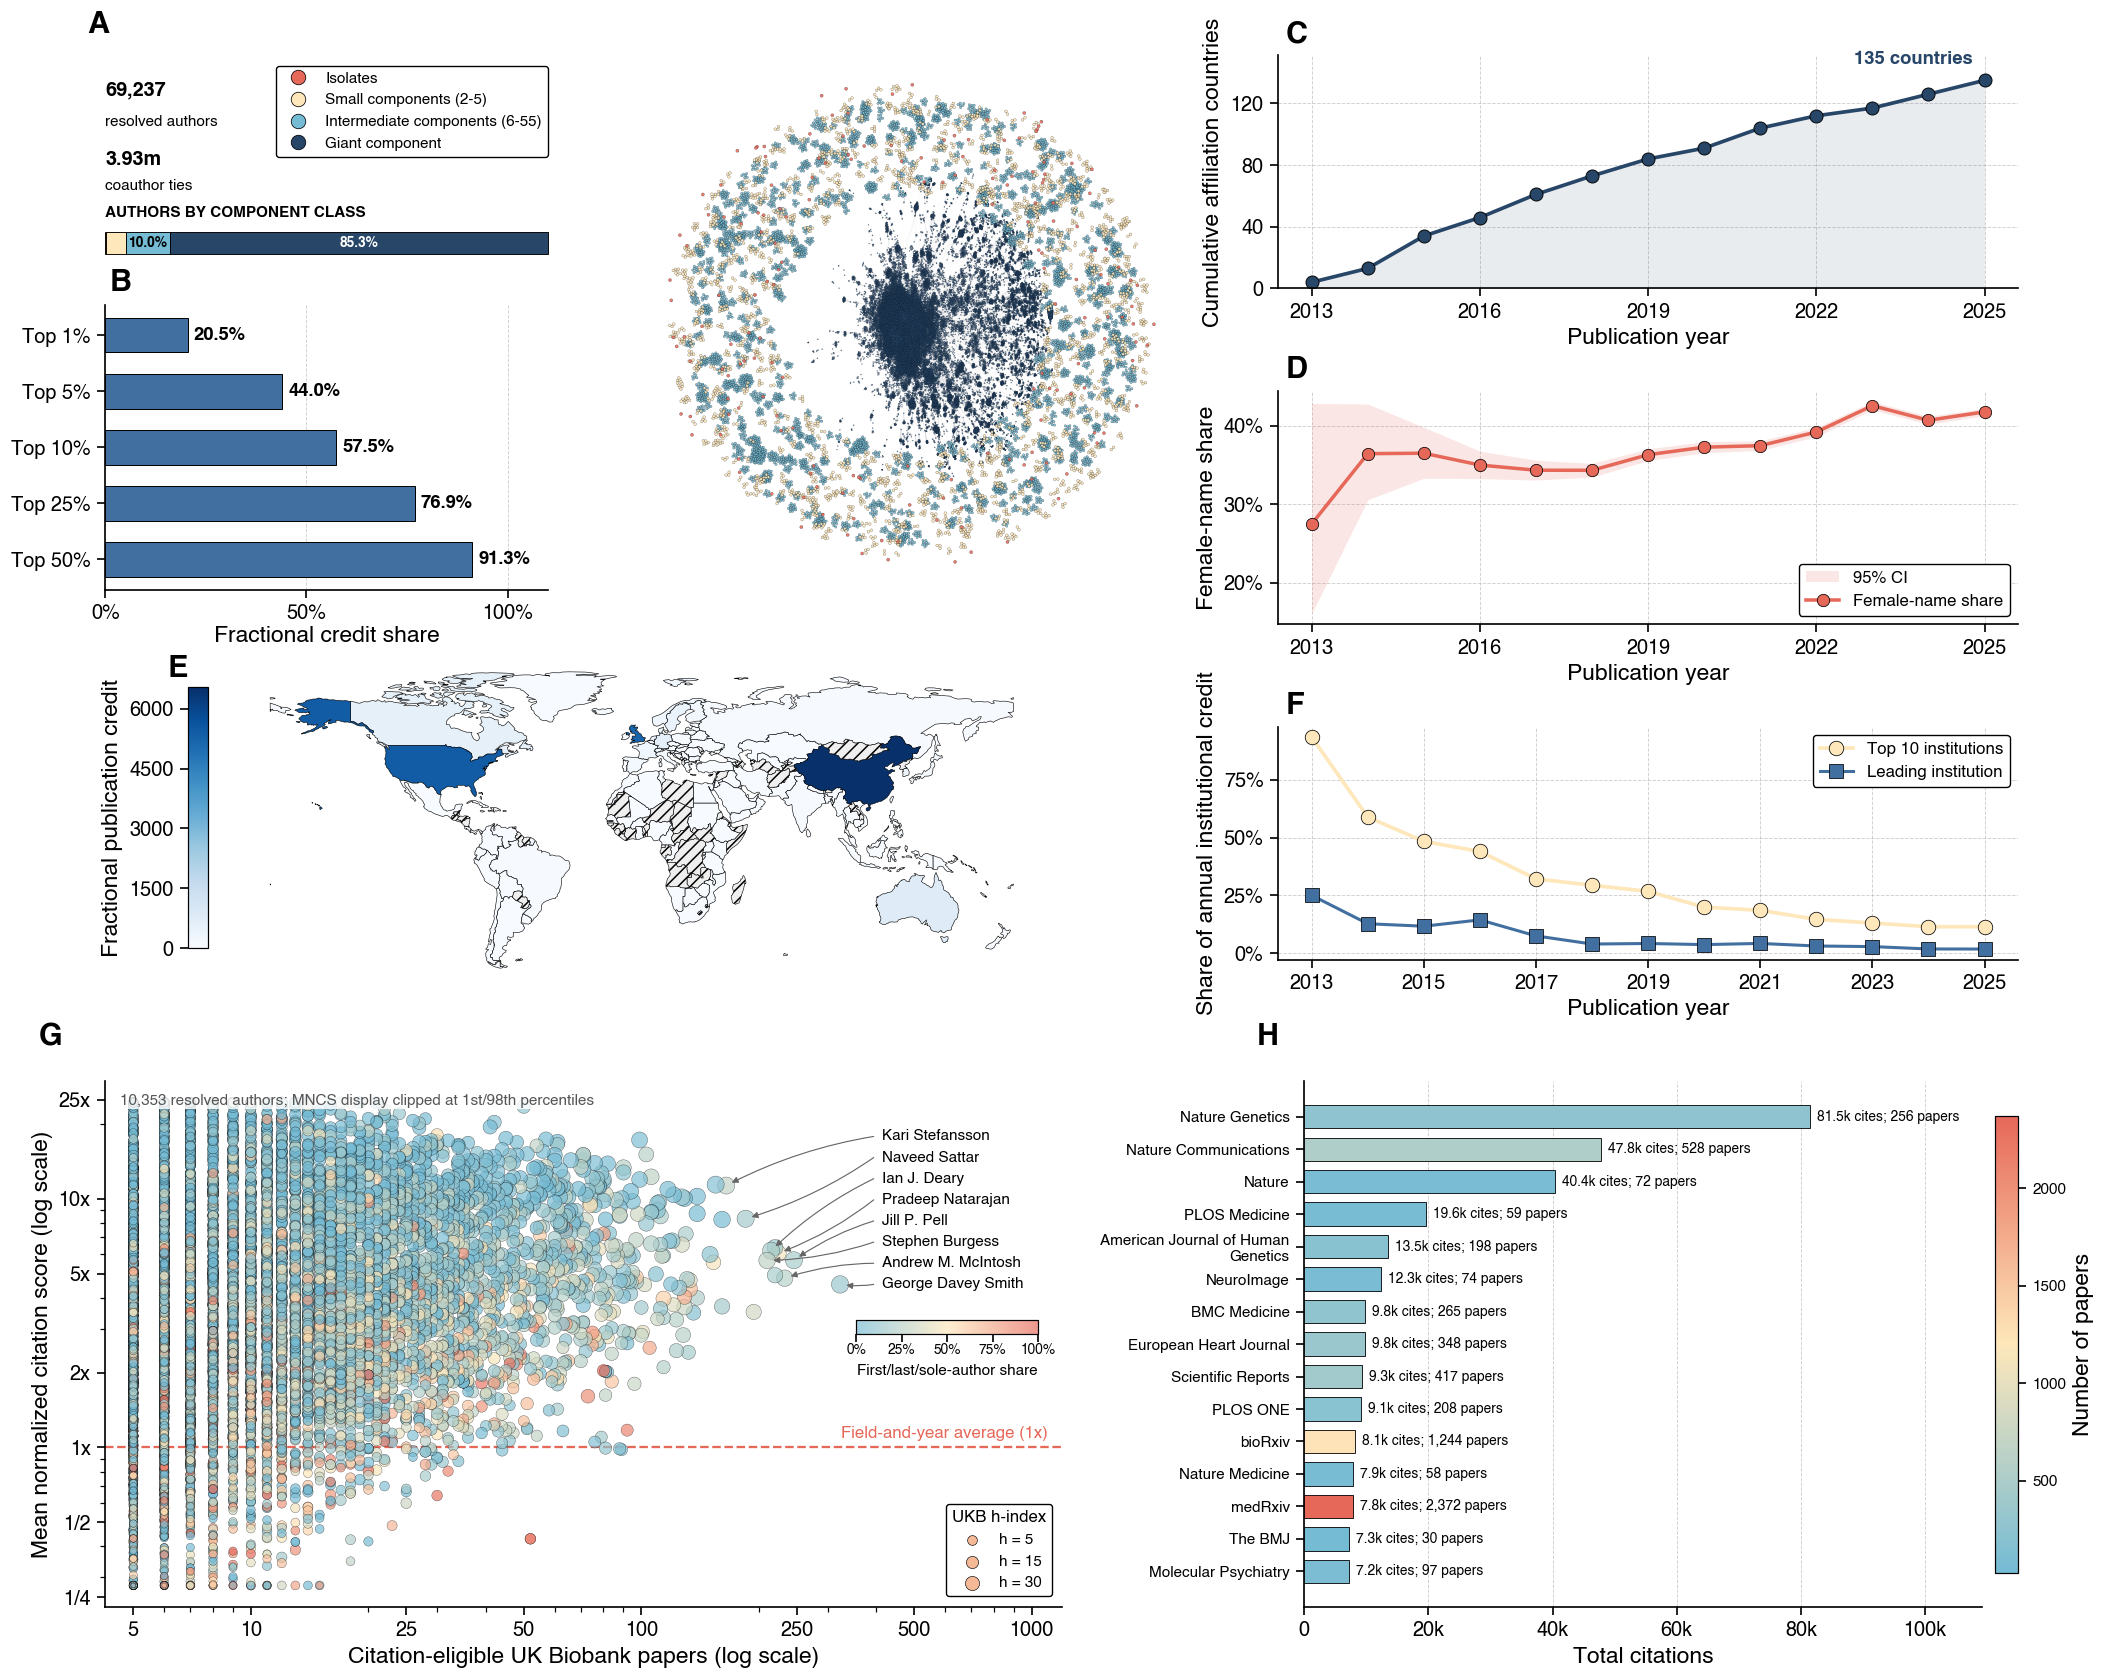

Saved: output/figures/data_analysis/05_author_characteristics/05_01_figure_03_author_characteristics.pdf
Saved: output/figures/data_analysis/05_author_characteristics/05_01_figure_03_author_characteristics.png


**Suggested caption:** Figure 3 | Characteristics and collaborative structure of authors using UK Biobank, 2013-2025. (A) Component-aware static coauthorship network with every resolved author plotted. Node colour distinguishes isolates, components of 2-5 authors, intermediate components and the giant component. All ties outside the giant component are shown; giant-component edges use a connected actual-edge backbone comprising a breadth-first tree and up to 80,000 repeated coauthorship ties. The stacked strip reports the share of resolved authors in each component class. (B) Cumulative shares of resolved-author fractional publication credit held by authors ranked in the top 1%, 5%, 10%, 25% and 50% of the credit distribution. (C) Cumulative number of unique author-affiliation countries observed through each publication year. (D) Annual share of author-paper pairs assigned to the Female name category among pairs assigned Female or Male, with 95% Wilson confidence intervals. Name categories are algorithmically inferred and are not self-identified gender. (E) Geographic distribution of fractional publication credit by author-affiliation country on a linear white-to-navy scale. (F) Annual concentration of observed institutional credit in the leading institution and leading ten institutions. (G) Citation-eligible resolved authors with at least 5 UK Biobank papers in 2013-2025, plotted by paper count and mean normalized citation score (MNCS) on logarithmic axes. The horizontal rule denotes field-and-year citation parity; marker area represents the UKB h-index and colour represents the share of first-, last- or sole-author papers. MNCS and h-index values use the frozen analysis 03 citation pathway. Values beyond the first and 98th MNCS percentiles are clipped for display only. (H) The 15 publication venues with the largest Showcase+ citation stock among venues contributing at least 20 papers from 2013-2025; bar colour represents paper count. Publications after 31 December 2025 were excluded.

In [8]:
headline = A.headline_statistics(core, network, impact)
display(headline)
_ = render_figure(
    F.plot_headline_figure,
    core,
    network,
    impact,
    STYLE,
    registry=ARTIFACTS,
)

## Supplementary Figure 1: author productivity and impact

This author-only supplement preserves the legacy bibliometric work and expands it with a full UKB h-index distribution, productivity survival curve, impact-productivity association, and ranked leading authors.

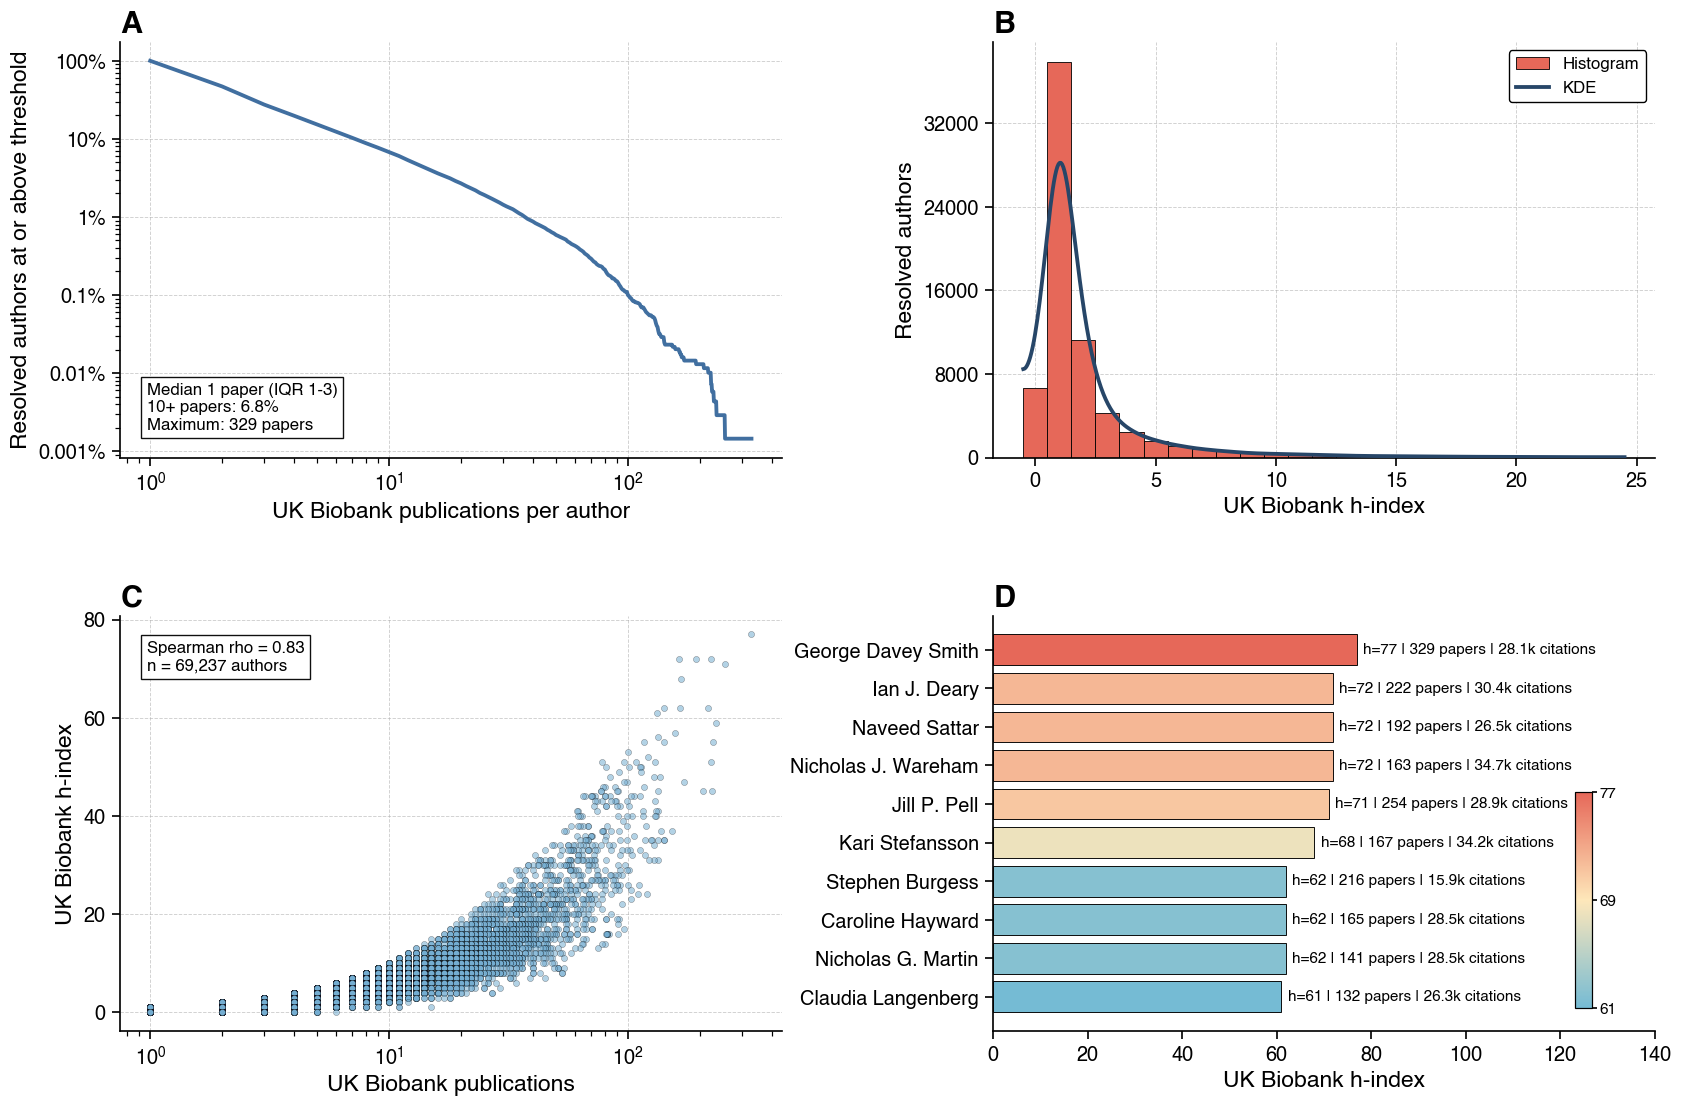

Saved: output/figures/data_analysis/05_author_characteristics/05_02_supplementary_figure_01_author_metrics.pdf
Saved: output/figures/data_analysis/05_author_characteristics/05_02_supplementary_figure_01_author_metrics.png


**Suggested caption:** Supplementary Figure 1 | UK Biobank-specific author productivity and impact. (A) Complementary cumulative distribution of publication counts, annotated with the median, interquartile range, upper-tail share and maximum. (B) Distribution of UKB h-index values, truncated at the 99.5th percentile for legibility and annotated with distributional summaries. (C) Association between UKB publication count and UKB h-index, with the Spearman rank correlation reported. (D) Authors with the ten highest UKB h-index values, with publication and citation counts. Citation measures are snapshot values and the UKB h-index uses only publications in the analysed corpus.

In [9]:
_ = render_figure(
    F.plot_author_metrics_supplement,
    core,
    STYLE,
    registry=ARTIFACTS,
)

## Supplementary Figure 2: name-inferred gender

This gender-only supplement emphasizes denominator transparency: composition counts, strict and expanded classification coverage, authorship position, and FOR division. Country and institution intersections are retained in exported tables rather than overloading the figure.

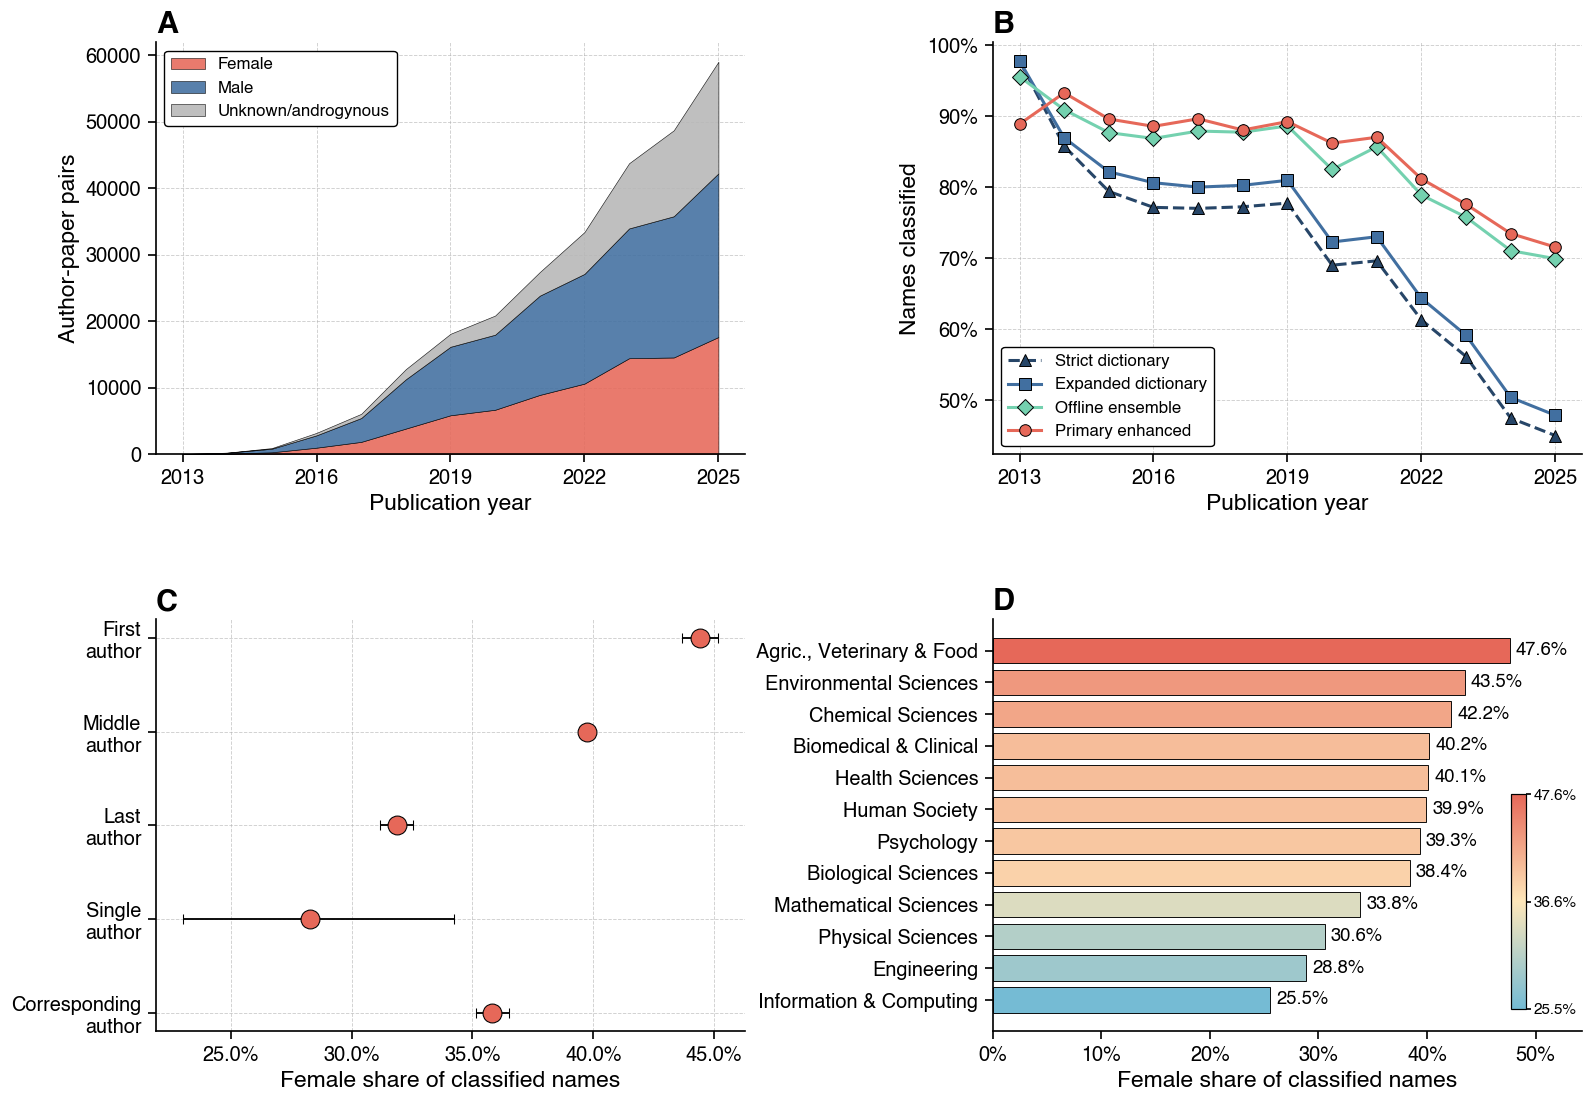

Saved: output/figures/data_analysis/05_author_characteristics/05_03_supplementary_figure_02_name_inferred_gender.pdf
Saved: output/figures/data_analysis/05_author_characteristics/05_03_supplementary_figure_02_name_inferred_gender.png


**Suggested caption:** Supplementary Figure 2 | Name-inferred gender composition of UK Biobank authorships. (A) Annual author-paper counts assigned Female, Male or Unknown/androgynous. (B) Annual classification coverage under strict dictionary, expanded dictionary, five-library offline ensemble and primary identity-linked rules. The ensemble uses only package-bundled local data with explicit disagreement thresholds; the primary rule adds conflict-safe linkage across records carrying the same Dimensions researcher ID. (C) Female-name share among classified names by authorship position, with 95% Wilson intervals. Corresponding authorship can overlap positional roles. (D) Female-name share in the 12 FOR divisions with the most classified author-paper memberships. Panel D uses a sequential blue scale for legibility, not a second variable. These binary categories are probabilistic proxies from names, not observed sex or self-identified gender; Unknown is retained because both error and non-classification vary culturally.

In [10]:
_ = render_figure(
    F.plot_gender_supplement,
    core,
    STYLE,
    registry=ARTIFACTS,
)

## Supplementary Figure 3: geographic maps

This map-only supplement separates the spatial evidence from the quantitative summaries. Author-affiliation and source research-organisation paper counts share one logarithmic colour scale, while author-paper intensity uses a separate logarithmic scale and a minimum evidence threshold.

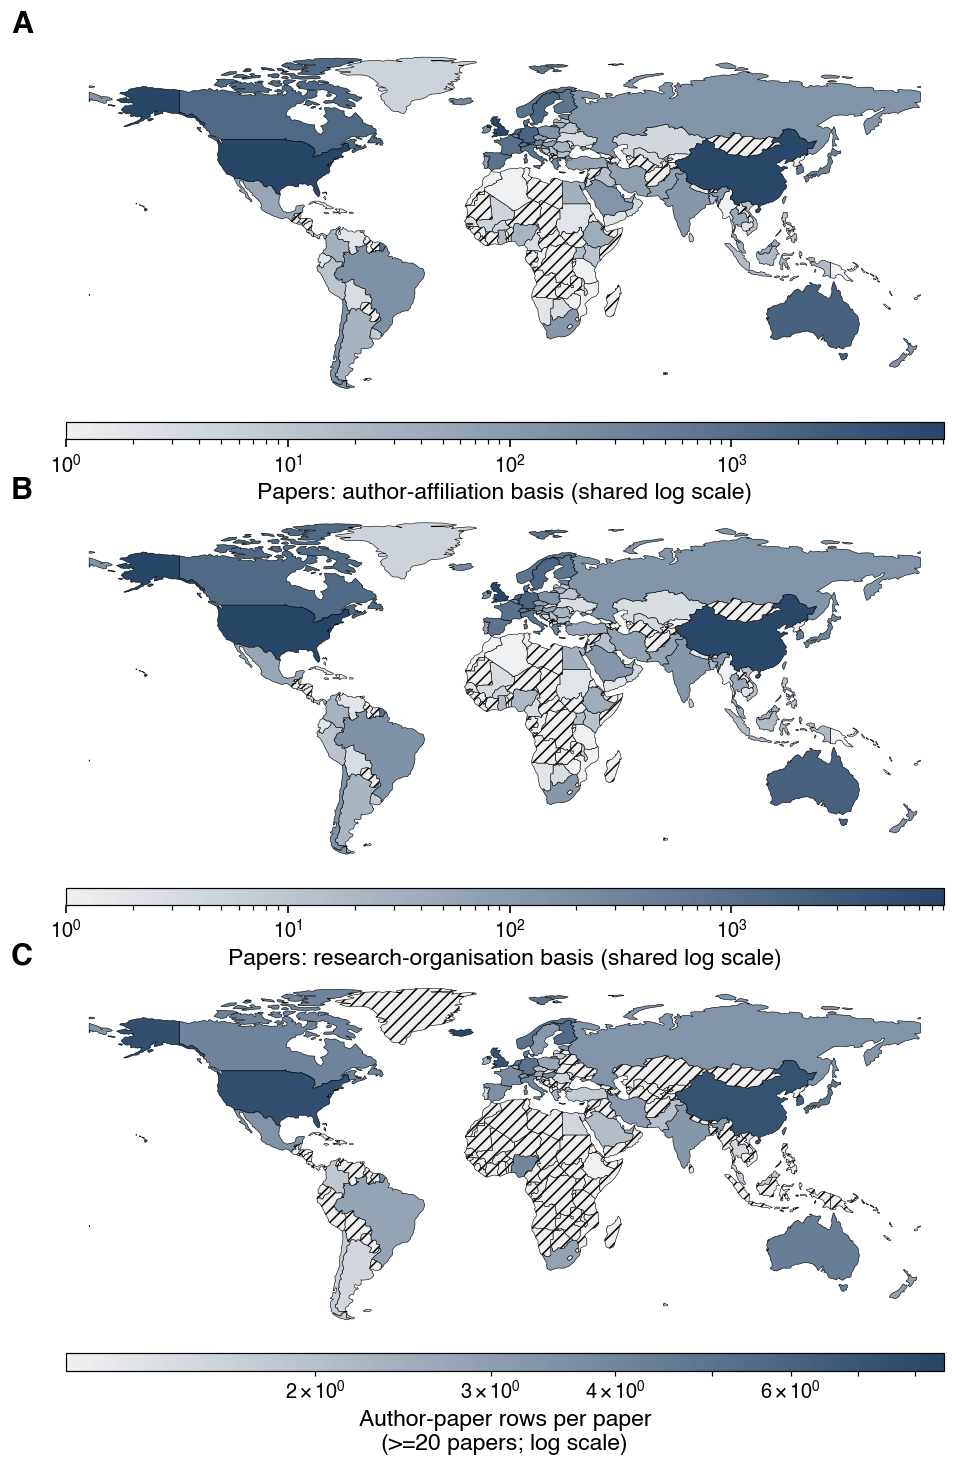

Saved: output/figures/data_analysis/05_author_characteristics/05_04_supplementary_figure_03_geography_maps.pdf
Saved: output/figures/data_analysis/05_author_characteristics/05_04_supplementary_figure_03_geography_maps.png


**Suggested caption:** Supplementary Figure 3 | Geographic distribution of UK Biobank authorship. (A) Distinct papers by author-affiliation country. (B) Distinct papers by the source publication's research-organisation countries. Panels A and B use a shared logarithmic colour scale. (C) Author-paper rows per paper among countries represented on at least 20 papers, shown on a separate logarithmic scale. Countries without eligible records are hatched, so that an absent record is not read as a low value at the pale end of the scale.

In [11]:
world = F.load_world_geometries()
_ = render_figure(
    F.plot_geography_maps_supplement,
    core,
    STYLE,
    world=world,
    registry=ARTIFACTS,
)

## Supplementary Figure 4: geographic reach and diversification

This quantitative geography supplement reports leading-country shares, country-level agreement between author-affiliation and source research-organisation definitions, period-specific country composition, and period-averaged entropy-based geographic diversity. The cumulative country-reach trajectory appears only in headline Figure 3C.

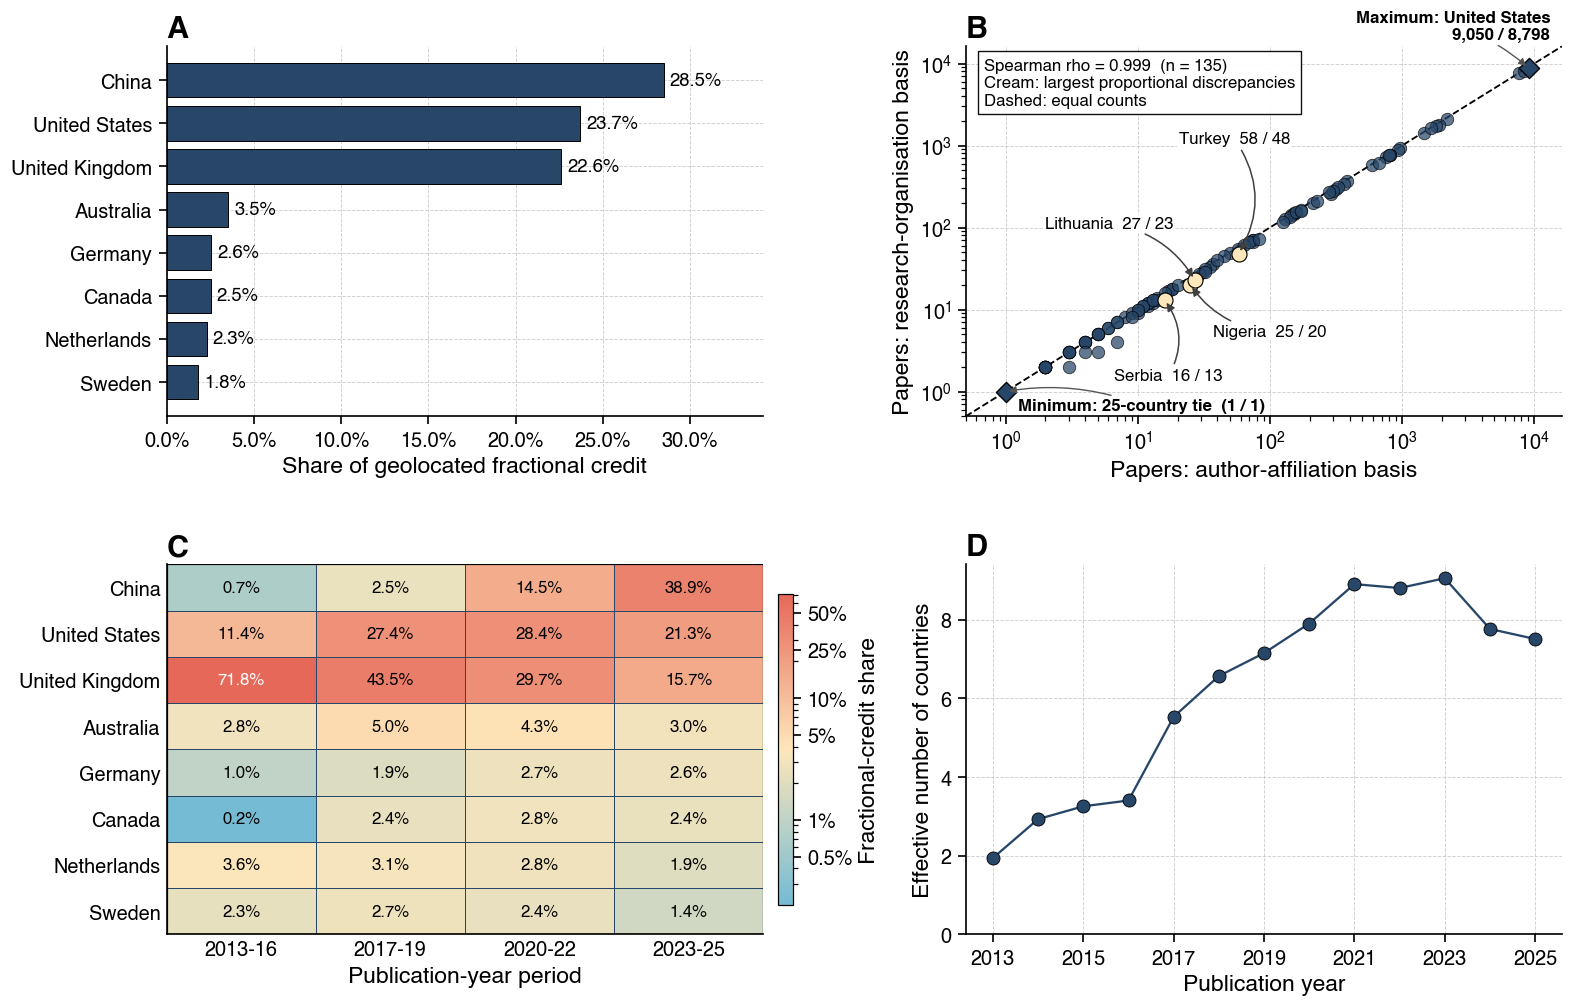

Saved: output/figures/data_analysis/05_author_characteristics/05_05_supplementary_figure_04_geography_metrics.pdf
Saved: output/figures/data_analysis/05_author_characteristics/05_05_supplementary_figure_04_geography_metrics.png


**Suggested caption:** Supplementary Figure 4 | Geographic reach and diversification of UK Biobank authorship. (A) Countries with the largest shares of geolocated fractional publication credit. (B) Country-level agreement between distinct paper counts from author-affiliation metadata and source research-organisation metadata, with a one-to-one reference and Spearman rank correlation; labelled countries have the largest proportional discrepancies among countries with at least ten papers under both definitions. Separate callouts identify the shared minimum-count point and the country with the largest geometric mean count across definitions. (C) Period-specific shares of geolocated fractional publication credit for the eight leading countries across all years; colour uses a logarithmic scale and annotations report the exact percentage. (D) Annual effective number of countries, defined as exponentiated Shannon entropy of each year's fractional country-credit shares. Credit is split across authors and each author's distinct affiliation countries; papers with unresolved geography retain their author credit but do not contribute to geolocated totals.

In [12]:
_ = render_figure(
    F.plot_geography_metrics_supplement,
    core,
    STYLE,
    registry=ARTIFACTS,
)

## Supplementary Figure 5: institutions

This institution-only supplement retains fractional leading-institution bars partitioned over the complete multi-label FOR taxonomy, cumulative institutional uptake, and the association between institutional UKB impact and fractional publication credit.

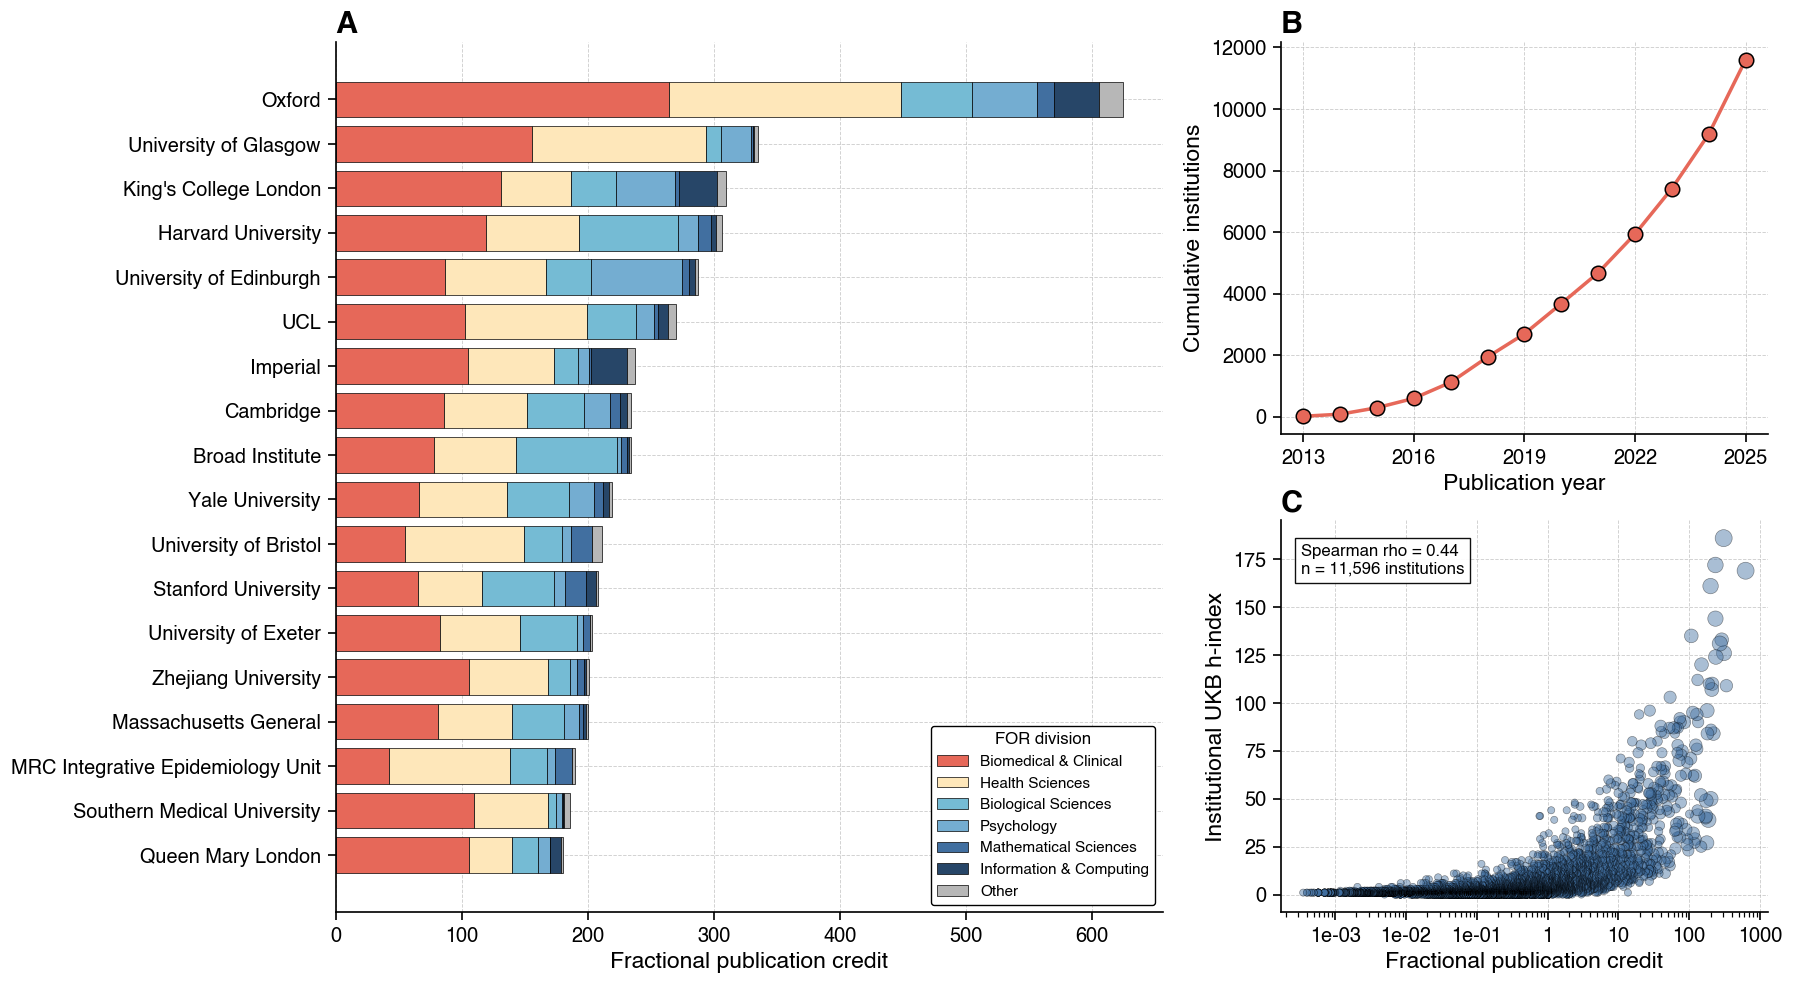

Saved: output/figures/data_analysis/05_author_characteristics/05_06_supplementary_figure_05_institutions.pdf
Saved: output/figures/data_analysis/05_author_characteristics/05_06_supplementary_figure_05_institutions.png


**Suggested caption:** Supplementary Figure 5 | Institutional participation in UK Biobank research. (A) Leading institutions by fractional publication credit, partitioned across all reported FOR L2 divisions with multi-label credit split equally. (B) Cumulative number of observed institutions. (C) Institutional UKB h-index against fractional publication credit, with the Spearman rank correlation reported; marker area reflects the number of resolved authors. Affiliations are fractional across authors and multiple affiliations.

In [13]:
_ = render_figure(
    F.plot_institution_supplement,
    core,
    STYLE,
    registry=ARTIFACTS,
)

## Supplementary Figure 6: coauthorship structure

This network-only supplement avoids repeating the headline topology. It reports FOR composition within the 12 largest Leiden communities, annual entry of newly resolved authors, the publication-collaborator association, tie-strength composition, component rank-size structure, and an endpoint hyperauthorship sensitivity. Complete annual network trajectories remain in the exported table.

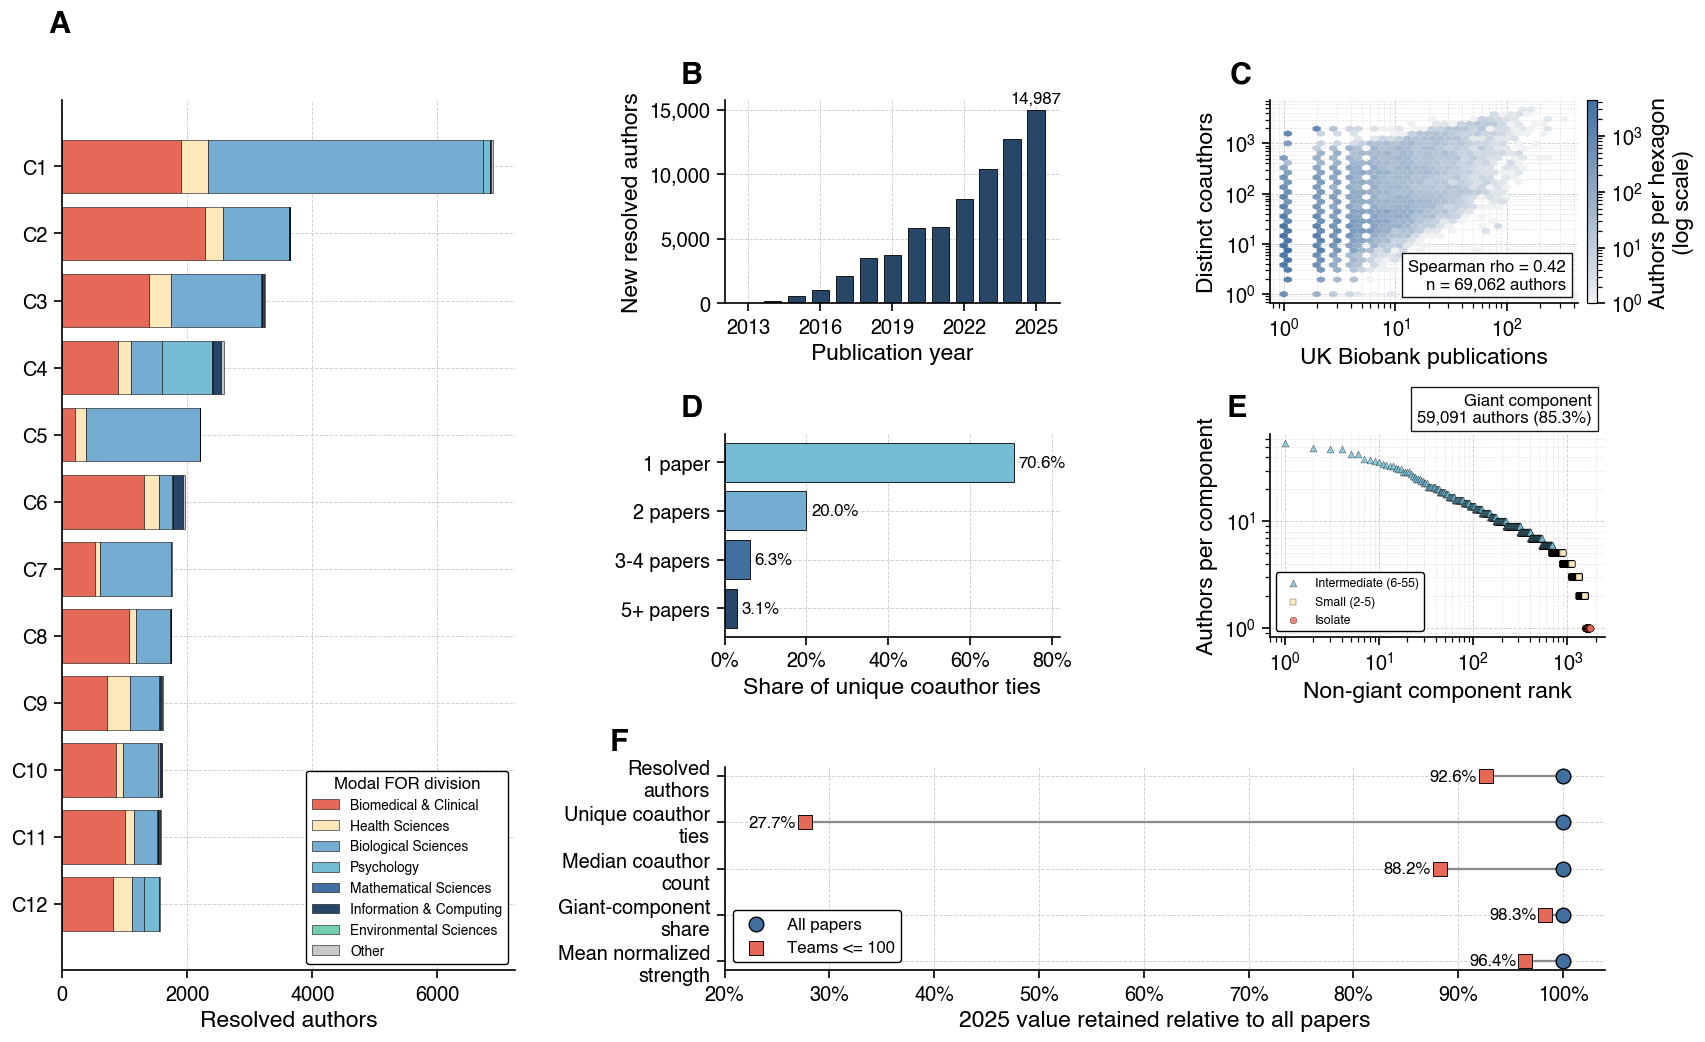

Saved: output/figures/data_analysis/05_author_characteristics/05_07_supplementary_figure_06_networks.pdf
Saved: output/figures/data_analysis/05_author_characteristics/05_07_supplementary_figure_06_networks.png


**Suggested caption:** Supplementary Figure 6 | UK Biobank coauthorship structure. (A) Modal FOR composition of the 12 largest Leiden communities in the full resolved-author network. (B) Newly resolved authors entering the cumulative network each year. (C) Association between UK Biobank publication count and the number of distinct coauthors among connected authors. Hexagon colour records author density on a logarithmic scale. (D) Distribution of unique coauthor ties by number of shared papers. (E) Rank-size distribution of non-giant connected components, with the giant-component endpoint reported separately to avoid compressing the smaller-component distribution. (F) Percentage of each 2025 endpoint retained after excluding papers with more than 100 resolved authors. Complete annual trajectories remain available in network_metrics_by_year.csv.

In [14]:
_ = render_figure(
    F.plot_network_supplement,
    core,
    network,
    STYLE,
    registry=ARTIFACTS,
)

## Tables, workbook, captions, methods, and manifest

The dedicated `top_30_authors_by_ukb_h_index.csv`, editable `.docx` table and matching workbook sheet provide the author-indexed ranking shown above. The complete exported author table merges productivity, UKB-specific citation indices, name category, conserved modal field/geography/institution assignments, current and fallback home institutions, authorship position, and network characteristics. Full community-by-L2, L4, institution, country, and name-category count/share/rank tables are exported alongside the compact plotted labels. Figure 3G-H additionally export the complete recurrent-author portfolio, selected author labels, complete venue ranking, and a source-provenance table. The legacy crosswalk records where every substantive former `05_*` output and each promoted analysis 03 figure now appears.

In [15]:
exports = A.export_analysis_artifacts(ARTIFACTS, source, papers, core, network, impact)
manifest, manifest_path = ARTIFACTS.save_manifest("author_characteristics_manifest.csv")
display(exports["headline"])
display(exports["audit"])
display(exports["checks"])
display(manifest.groupby(["kind", "format"]).size().unstack(fill_value=0))
display(Markdown("**Analysis complete.** All displayed and exported paths are repository-relative."))

saved output/tables/data_analysis/05_author_characteristics/top_30_authors_by_ukb_h_index.csv


saved output/tables/data_analysis/05_author_characteristics/top_30_authors_by_ukb_h_index.docx


saved output/tables/data_analysis/05_author_characteristics/author_metrics.csv
saved output/tables/data_analysis/05_author_characteristics/author_credit_concentration.csv
saved output/tables/data_analysis/05_author_characteristics/author_productivity_bands.csv
saved output/tables/data_analysis/05_author_characteristics/paper_for_assignments.csv
saved output/tables/data_analysis/05_author_characteristics/institution_metrics.csv
saved output/tables/data_analysis/05_author_characteristics/country_metrics.csv
saved output/tables/data_analysis/05_author_characteristics/gender_by_year.csv
saved output/tables/data_analysis/05_author_characteristics/gender_by_authorship_role.csv
saved output/tables/data_analysis/05_author_characteristics/gender_by_for_division.csv
saved output/tables/data_analysis/05_author_characteristics/gender_by_country.csv
saved output/tables/data_analysis/05_author_characteristics/gender_by_institution.csv


saved output/tables/data_analysis/05_author_characteristics/name_gender_inference_coverage.csv
saved output/tables/data_analysis/05_author_characteristics/name_gender_inference_coverage_by_year.csv
saved output/tables/data_analysis/05_author_characteristics/name_gender_inference_method_counts.csv
saved output/tables/data_analysis/05_author_characteristics/name_gender_offline_library_audit.csv
saved output/tables/data_analysis/05_author_characteristics/name_gender_offline_library_versions.csv
saved output/tables/data_analysis/05_author_characteristics/name_gender_unresolved_queries.csv
saved output/tables/data_analysis/05_author_characteristics/country_metrics_by_year.csv
saved output/tables/data_analysis/05_author_characteristics/institution_metrics_by_year.csv
saved output/tables/data_analysis/05_author_characteristics/network_metrics_by_year.csv
saved output/tables/data_analysis/05_author_characteristics/network_author_metrics.csv


saved output/tables/data_analysis/05_author_characteristics/network_community_membership.csv
saved output/tables/data_analysis/05_author_characteristics/network_community_summary.csv
saved output/tables/data_analysis/05_author_characteristics/network_collapsed_nodes.csv
saved output/tables/data_analysis/05_author_characteristics/network_collapsed_edges.csv
saved output/tables/data_analysis/05_author_characteristics/headline_author_impact_portfolio.csv
saved output/tables/data_analysis/05_author_characteristics/headline_author_impact_labels.csv
saved output/tables/data_analysis/05_author_characteristics/headline_venue_impact.csv
saved output/tables/data_analysis/05_author_characteristics/headline_impact_provenance.csv
saved output/tables/data_analysis/05_author_characteristics/headline_summary_statistics.csv
saved output/tables/data_analysis/05_author_characteristics/data_quality_audit.csv
saved output/tables/data_analysis/05_author_characteristics/analysis_validation_checks.csv
saved o

...

,statistic,value,unit_or_definition
0,Resolved authors,69237,authors
1,Author-paper pairs,274603,authorships
2,Authors with one UKB paper,53.035227,% resolved authors
3,Author credit Gini,0.685374,0=equality; 1=concentration
4,Credit held by top 1% of authors,20.490964,% resolved-author fractional publication credit
5,Credit held by top 5% of authors,43.976837,% resolved-author fractional publication credit
6,Credit held by top 10% of authors,57.462446,% resolved-author fractional publication credit
7,Credit held by top 25% of authors,76.880887,% resolved-author fractional publication credit
8,Credit held by top 50% of authors,91.253194,% resolved-author fractional publication credit
9,"Female-name share, 2013",27.5,% classified authorships


,metric,value,interpretation
0,Source parquet records,26109.00,includes provisional years
1,Records before 2013,0.00,excluded from primary analysis
2,Records after 2025,2667.00,excluded from primary analysis
3,Complete-year papers,23442.00,2013-2025
4,Papers with parsed authors,23407.00,author-based denominator
5,Papers without parsed authors,35.00,retained in source audit only
6,Parsed author-paper pairs,274603.00,deduplicated within paper
7,Resolved author-paper pairs,242663.00,Dimensions researcher ID present
8,Unresolved author-paper pairs,31940.00,paper-local IDs; never merged by name
9,Unique resolved authors,69237.00,author table rows


,check,passed,observed,expected
0,unique_source_publication_ids,True,26109,26109
1,complete_year_window,True,2013-2025,2013-2025
2,publication_date_cutoff,True,23442,2025-12-31
3,unique_author_paper_pairs,True,274603,274603
4,authorship_credit_sums_to_one,True,0.0,<=1e-9
5,country_credit_never_exceeds_one,True,1.0,<=1
6,institution_credit_never_exceeds_one,True,1.0,<=1
7,institution_credit_conserved,True,0.0,<=1e-9
8,country_credit_conserved,True,0.0,<=1e-9
9,fractional_credits_nonnegative,True,nonnegative,nonnegative


format,csv,docx,pdf,png,txt,xlsx
kind,,,,,,
figure,0,0,7,7,0,0
table_or_text,57,1,0,0,1,1


**Analysis complete.** All displayed and exported paths are repository-relative.